# Reddit Research: Taoism

## 5. Statistical Analysis 

In this notebook, we conduct a statistical analysis of user discourse on the Taoism subreddit, focusing on the affective and rhetorical patterns present in user comments. Drawing on previously annotated sentiment, emotion, topic, and rhetorical labels, we aim to explore underlying relationships and frequencies across variables such as emotion type, sentiment polarity, and community engagement (measured via comment score). The analysis will begin with basic descriptive statistics to summarize key features of the dataset. We will then examine the distribution and co-occurrence of emotions and sentiments, followed by statistical tests to identify potential associations between affective categories and rhetorical strategies. Finally, we will assess whether certain emotions or sentiments are linked to greater engagement within the community.

### Descriptive Statistics

In [56]:
import pandas as pd

In [58]:
comments_df = pd.read_csv("../data/taoism_comments_labeled_with_sentiment_emotion.csv")

In [60]:
# Descriptive Statistics of Taoism Subreddit Comments
import matplotlib.pyplot as plt
import seaborn as sns

# Basic Counts
num_comments = len(comments_df)
num_authors = comments_df['author'].nunique()

print(f"Total number of comments: {num_comments}")
print(f"Total number of unique authors: {num_authors}")

Total number of comments: 1981
Total number of unique authors: 482


Average comment length: 412.37 characters
Median comment length: 193.0 characters


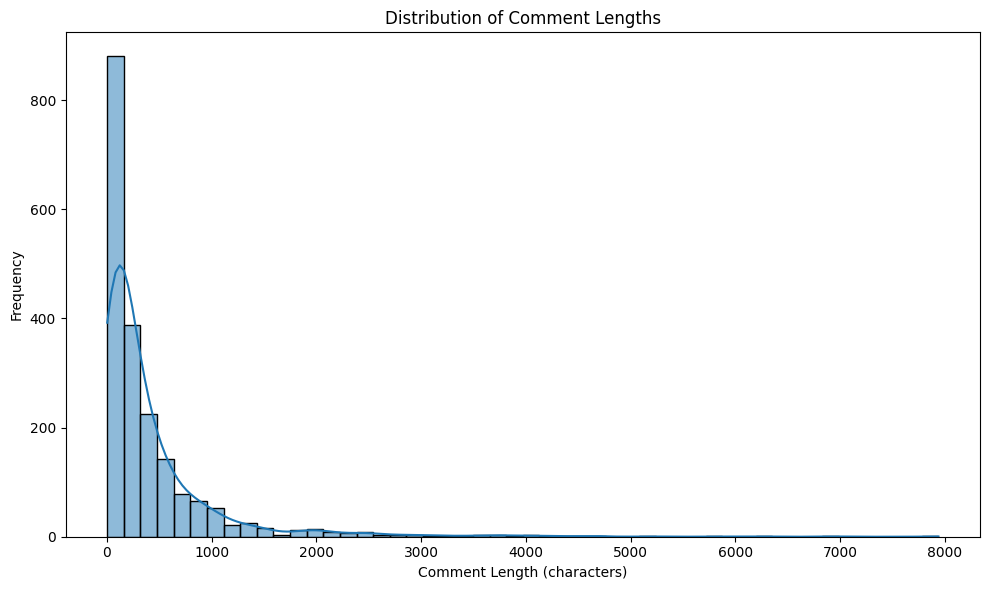

In [62]:
# Comment Length Analysis
comments_df['comment_length'] = comments_df['body'].str.len()

avg_length = comments_df['comment_length'].mean()
median_length = comments_df['comment_length'].median()

print(f"Average comment length: {avg_length:.2f} characters")
print(f"Median comment length: {median_length} characters")

# Plot: Distribution of comment lengths
plt.figure(figsize=(10, 6))
sns.histplot(comments_df['comment_length'], bins=50, kde=True)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length (characters)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


Score (upvote) statistics:
count    1981.000000
mean        3.164563
std         6.770418
min       -25.000000
25%         1.000000
50%         2.000000
75%         3.000000
max       163.000000
Name: score, dtype: float64


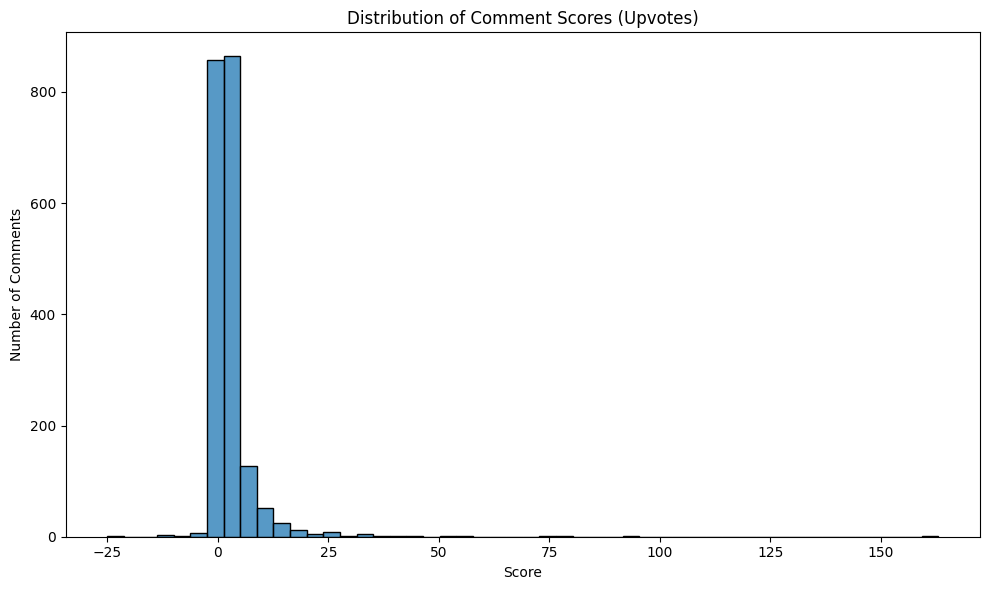

In [67]:
# Score Distribution
print(f"\nScore (upvote) statistics:")
print(comments_df['score'].describe())

# Plot: Distribution of scores
plt.figure(figsize=(10, 6))
sns.histplot(comments_df['score'], bins=50, kde=False)
plt.title('Distribution of Comment Scores (Upvotes)')
plt.xlabel('Score')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()


The dataset comprises a total of 1,981 comments written by 482 unique authors, indicating a moderate level of user engagement with repeated participation by some users. The average comment length is approximately 412 characters, while the median is lower at 193 characters, reflecting a skewed distribution where most comments are short, but a subset of users contribute much longer responses. Regarding community feedback, the average comment score is 3.15, with a median of 2 and a standard deviation of 6.72. The score distribution is also skewed, with most comments receiving low engagement, while a few outliers achieve high visibility (maximum score 163) or strong negative feedback (minimum -25), suggesting that certain posts resonate particularly well or spark controversy.

### Emotion and Sentiment Distribution

Now we will explore the overall distribution of emotions and sentiment in the Taoism subreddit comments. We first examine the frequency of each detected top emotion and sentiment label to understand the prevailing affective tone in the dataset. We then calculate the average sentiment score per emotion, providing additional nuance about how strongly positive or negative each emotional category tends to be.

Top Emotion Counts:
top_emotion
joy         1243
anger        441
sadness      174
fear          80
surprise      27
love          16
Name: count, dtype: int64


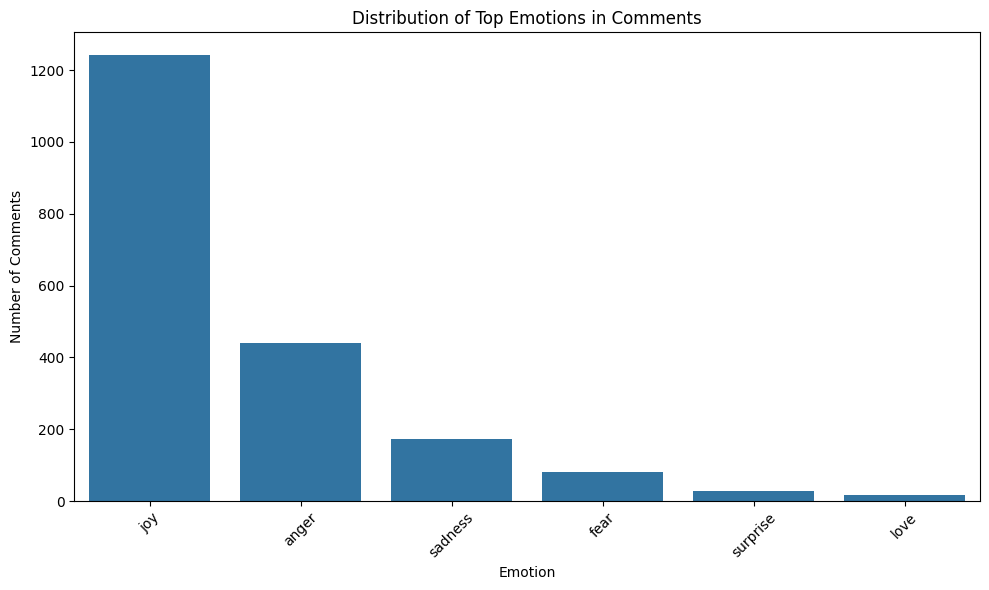

In [70]:
# Frequency of Emotions
emotion_counts = comments_df['top_emotion'].value_counts().sort_values(ascending=False)
print("Top Emotion Counts:")
print(emotion_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title("Distribution of Top Emotions in Comments")
plt.xlabel("Emotion")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Sentiment Label Counts:
sentiment_label
neutral     1070
positive     476
negative     435
Name: count, dtype: int64


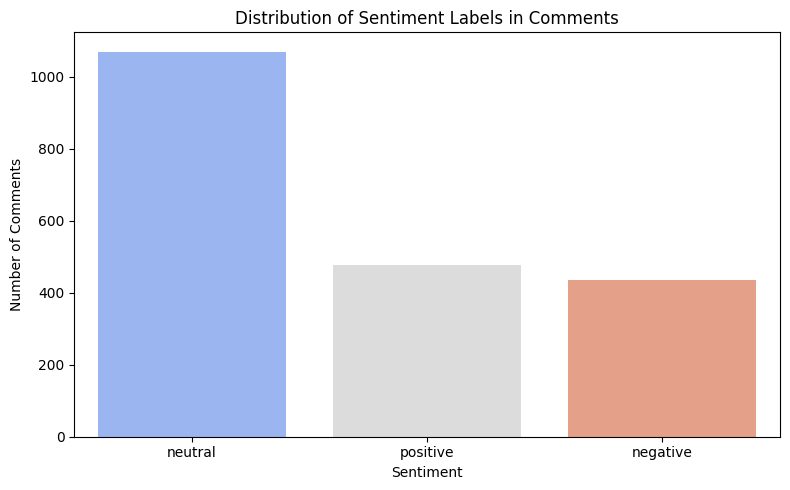

In [72]:
# Frequency of Sentiment Labels
sentiment_counts = comments_df['sentiment_label'].value_counts().sort_values(ascending=False)
print("\nSentiment Label Counts:")
print(sentiment_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index, legend=False, palette='coolwarm')
plt.title("Distribution of Sentiment Labels in Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()


Average Sentiment Score per Emotion:
top_emotion
love        0.747362
joy         0.686555
anger       0.665558
fear        0.664948
sadness     0.642335
surprise    0.636943
Name: sentiment_score, dtype: float64


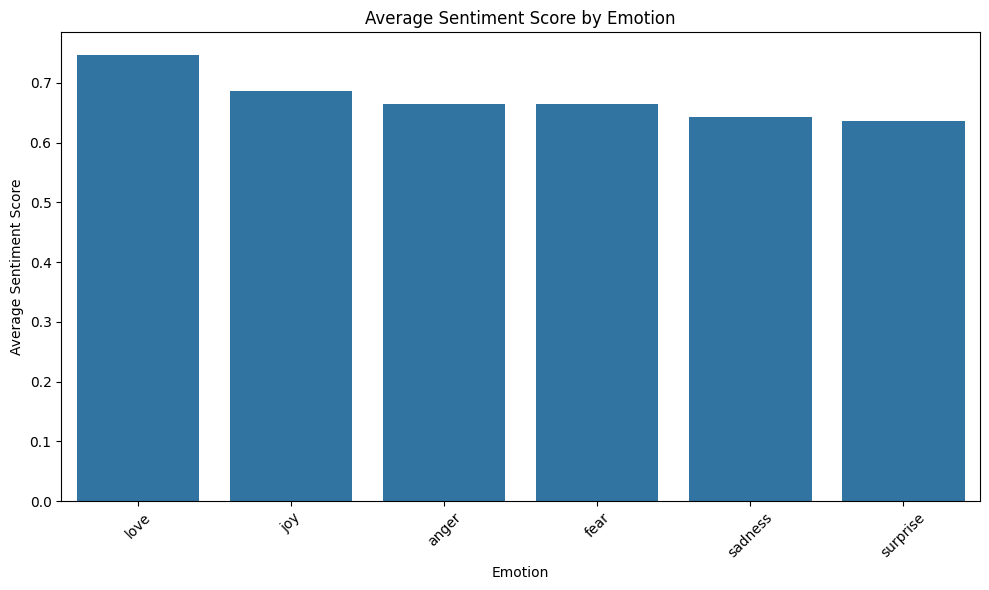

In [74]:
# Average Sentiment Score per Emotion
sentiment_by_emotion = comments_df.groupby('top_emotion')['sentiment_score'].mean().sort_values(ascending=False)
print("\nAverage Sentiment Score per Emotion:")
print(sentiment_by_emotion)

plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_by_emotion.index, y=sentiment_by_emotion.values)
plt.title("Average Sentiment Score by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The results show that joy is by far the most frequent top emotion, followed by anger and sadness, with fear, surprise, and love appearing much less often. Sentiment-wise, the majority of comments are labeled as neutral, with roughly equal numbers of positive and negative comments. When looking at average sentiment scores, love and joy unsurprisingly exhibit the highest positivity, while emotions such as anger, fear, and sadness have lower, though still generally positive, sentiment scores—suggesting that even when users express more difficult emotions, the overall tone remains relatively constructive.

### Chi-Squared

In this section, we apply chi-squared tests to examine potential associations between emotions, sentiment labels, and rhetorical categories. We first test whether emotion and sentiment are statistically independent, and then assess whether rhetorical strategy is related to the type of emotion expressed. These tests allow us to detect whether affective patterns are systematically linked to different communicative styles in the subreddit.

In [78]:
# Chi-squared test: Are top_emotion and sentiment_label independent?
from scipy.stats import chi2_contingency

# Create contingency table
emotion_sentiment_ct = pd.crosstab(comments_df['top_emotion'], comments_df['sentiment_label'])

# Perform chi-squared test
chi2, p, dof, expected = chi2_contingency(emotion_sentiment_ct)

print("Chi-squared test for Emotion vs Sentiment")
print(f"Chi² statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("Result: There is a statistically significant relationship between emotion and sentiment.")
else:
    print("Result: No significant relationship found between emotion and sentiment.")


Chi-squared test for Emotion vs Sentiment
Chi² statistic: 289.91
Degrees of freedom: 10
P-value: 0.0000
Result: There is a statistically significant relationship between emotion and sentiment.


In [80]:
# Chi-squared test: Are top_emotion and rhetoric category independent?

# Drop NA values in 'rhetoric' to avoid errors
filtered_df = comments_df.dropna(subset=['rhetoric', 'top_emotion'])

# Create contingency table
emotion_rhetoric_ct = pd.crosstab(filtered_df['top_emotion'], filtered_df['rhetoric'])

# Perform chi-squared test
chi2_rh, p_rh, dof_rh, expected_rh = chi2_contingency(emotion_rhetoric_ct)

print("Chi-squared test for Emotion vs Rhetoric")
print(f"Chi² statistic: {chi2_rh:.2f}")
print(f"Degrees of freedom: {dof_rh}")
print(f"P-value: {p_rh:.4f}")

if p_rh < 0.05:
    print("Result: There is a statistically significant relationship between emotion and rhetorical category.")
else:
    print("Result: No significant relationship found between emotion and rhetorical category.")


Chi-squared test for Emotion vs Rhetoric
Chi² statistic: 68.56
Degrees of freedom: 10
P-value: 0.0000
Result: There is a statistically significant relationship between emotion and rhetorical category.


The results indicate that both tested relationships are statistically significant. There is a strong association between emotion and sentiment (χ² = 289.91, p < 0.0001), confirming that certain emotions tend to align with specific sentiment labels. Similarly, the relationship between emotion and rhetorical category is also significant (χ² = 68.56, p < 0.0001), suggesting that different rhetorical strategies are associated with distinct emotional tones in the discourse. These findings highlight how emotional expression and argumentative style are intertwined in the Taoist subreddit community.

To further illustrate the significant relationships detected in the chi-squared tests, we visualize the cross-tabulations of emotion vs sentiment label and emotion vs rhetorical category using heatmaps. These charts allow us to observe how emotional expressions are distributed across different sentiment polarities and rhetorical strategies within the subreddit discourse.

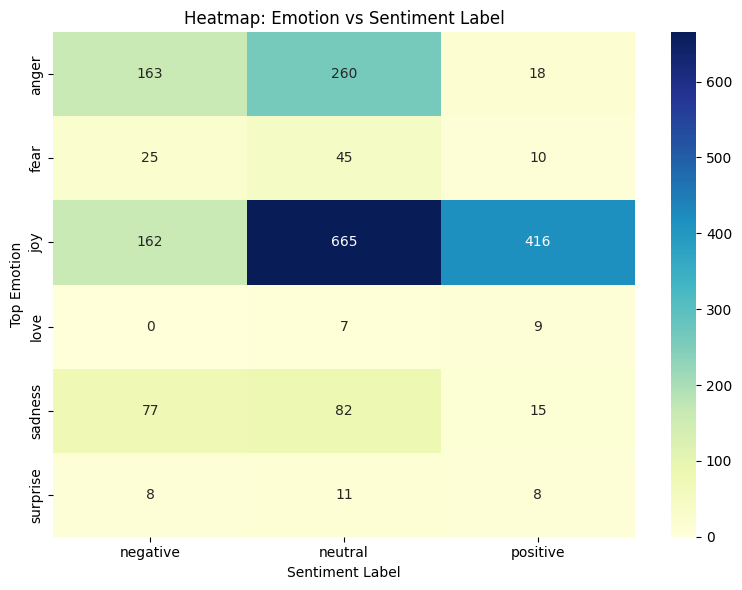

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap: Emotion vs Sentiment
plt.figure(figsize=(8, 6))
sns.heatmap(emotion_sentiment_ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Heatmap: Emotion vs Sentiment Label")
plt.xlabel("Sentiment Label")
plt.ylabel("Top Emotion")
plt.tight_layout()
plt.show()

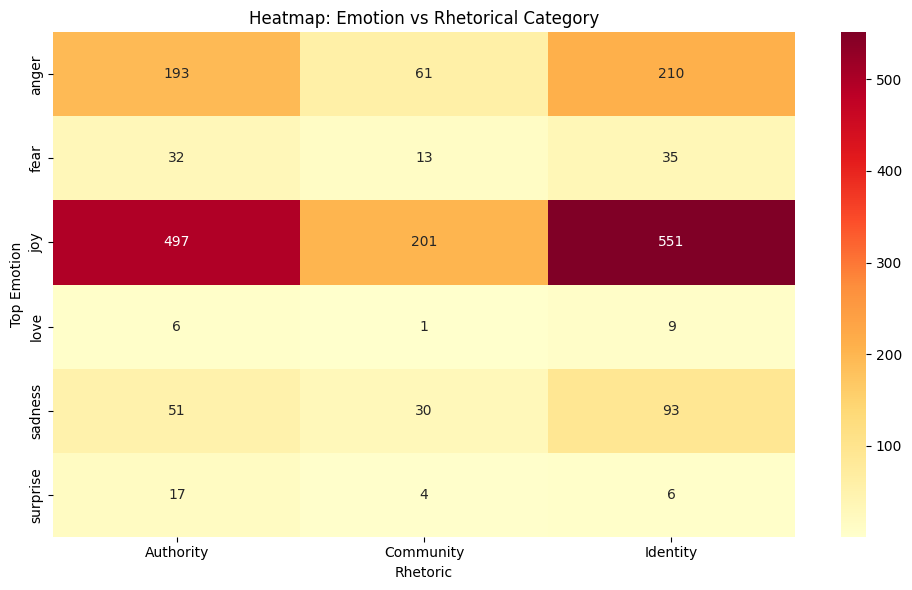

In [42]:
# Heatmap: Emotion vs Rhetoric
plt.figure(figsize=(10, 6))
sns.heatmap(emotion_rhetoric_ct, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Heatmap: Emotion vs Rhetorical Category")
plt.xlabel("Rhetoric")
plt.ylabel("Top Emotion")
plt.tight_layout()
plt.show()

The heatmaps confirm that certain emotions are strongly aligned with specific sentiment labels: joy is primarily associated with neutral and positive sentiments, while anger, sadness, and fear are more often linked to neutral or negative sentiments. Similarly, the distribution of emotions varies across rhetorical categories: joy dominates in Identity and Authority rhetoric, while anger is more prominent in Authority and Identity as well. These patterns highlight how affective tone and argumentative style interact in shaping the emotional dynamics of the community.



## Conclusion

In this notebook, we conducted a statistical analysis of affective and rhetorical patterns in the Taoism subreddit. Our results show that emotional expression is not randomly distributed across either sentiment labels or rhetorical strategies. Joy emerged as the most dominant emotion, particularly associated with neutral and positive sentiments, and was prevalent in both Identity and Authority rhetoric. Meanwhile, anger, sadness, and fear were more frequently linked to neutral or negative sentiments and appeared more often in Authority discourse. These findings suggest that emotional tone and rhetorical style are closely intertwined in the community’s discussions, reflecting the ways in which users navigate spiritual identity, interpret teachings, and engage in argumentative exchanges within this online space.